In [31]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np 
from torch.utils.data import Dataset
import random
import os

In [32]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [33]:
text="""In the beginning God created the heaven and the earth. And the earth was without form, and void; 
and darkness was upon the face of the deep. And the Spirit of God moved upon the face of the waters. And God said, Let there be light:
and there was light. And God saw the light, that it was good: and God divided the light from the darkness. And God called the light Day, 
and the darkness he called Night. And the evening and the morning were the first day."""
text = text.lower()
print(f'Length of text: {len(text)} characters')
print(text[:100])

Length of text: 456 characters
in the beginning god created the heaven and the earth. and the earth was without form, and void; 
an


In [34]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
char_to_idx = {ch: idx for idx, ch in enumerate(chars)}
idx_to_char = {idx: ch for idx, ch in enumerate(chars)}
print(f'Unique characters: {chars}')
print(f'Vocabulary size: {vocab_size}')

Unique characters: ['\n', ' ', ',', '.', ':', ';', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'w', 'y']
Vocabulary size: 28


In [36]:
def encode(s):
    return [char_to_idx[ch] for ch in s]
def decode(indices):
    return ''.join([idx_to_char[idx] for idx in indices])
encoded_text = encode(text)
print(f'Encoded text: {encoded_text[:100]}')
print(f'Decoded text: {decode(encoded_text[:100])}')

Encoded text: [14, 18, 1, 23, 13, 10, 1, 7, 10, 12, 14, 18, 18, 14, 18, 12, 1, 12, 19, 9, 1, 8, 21, 10, 6, 23, 10, 9, 1, 23, 13, 10, 1, 13, 10, 6, 25, 10, 18, 1, 6, 18, 9, 1, 23, 13, 10, 1, 10, 6, 21, 23, 13, 3, 1, 6, 18, 9, 1, 23, 13, 10, 1, 10, 6, 21, 23, 13, 1, 26, 6, 22, 1, 26, 14, 23, 13, 19, 24, 23, 1, 11, 19, 21, 17, 2, 1, 6, 18, 9, 1, 25, 19, 14, 9, 5, 1, 0, 6, 18]
Decoded text: in the beginning god created the heaven and the earth. and the earth was without form, and void; 
an


In [35]:
seq_length = 50
input_sequences = []
target_sequences = []
for i in range(len(encoded_text) - seq_length):
    input_seq = encoded_text[i:i+seq_length]
    target_seq = encoded_text[i+1:i+seq_length+1]
    input_sequences.append(input_seq)
    target_sequences.append(target_seq)
print(f'Number of sequences: {len(input_sequences)}')
print(f'Example input sequence: {input_sequences[0]}')
print(f'Example target sequence: {target_sequences[0]}')
print(f'Example input text: {decode(input_sequences[0])}')
print(f'Example target text: {decode(target_sequences[0])}')

Number of sequences: 406
Example input sequence: [14, 18, 1, 23, 13, 10, 1, 7, 10, 12, 14, 18, 18, 14, 18, 12, 1, 12, 19, 9, 1, 8, 21, 10, 6, 23, 10, 9, 1, 23, 13, 10, 1, 13, 10, 6, 25, 10, 18, 1, 6, 18, 9, 1, 23, 13, 10, 1, 10, 6]
Example target sequence: [18, 1, 23, 13, 10, 1, 7, 10, 12, 14, 18, 18, 14, 18, 12, 1, 12, 19, 9, 1, 8, 21, 10, 6, 23, 10, 9, 1, 23, 13, 10, 1, 13, 10, 6, 25, 10, 18, 1, 6, 18, 9, 1, 23, 13, 10, 1, 10, 6, 21]
Example input text: in the beginning god created the heaven and the ea
Example target text: n the beginning god created the heaven and the ear


In [37]:
class TextDataset(Dataset):
    def __init__(self, input_seqs, target_seqs):
        self.input_seqs = input_seqs
        self.target_seqs = target_seqs
    def __len__(self):
        return len(self.input_seqs)
    def __getitem__(self, idx):
        return torch.tensor(self.input_seqs[idx], dtype=torch.long), torch.tensor(self.target_seqs[idx], dtype=torch.long)

In [38]:
dataset = TextDataset(input_sequences, target_sequences)
batch_size = 16
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
for batch_inputs, batch_targets in dataloader:
    print(f'Batch input shape: {batch_inputs.shape}')  # (batch_size, seq_length)
    print(f'Batch target shape: {batch_targets.shape}')  # (batch_size, seq_length)
    break

Batch input shape: torch.Size([16, 50])
Batch target shape: torch.Size([16, 50])


In [39]:
dataset = TextDataset(input_sequences, target_sequences)
batch_size = 16
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
for batch_inputs, batch_targets in dataloader:
    print(f'Batch input shape: {batch_inputs.shape}')  # (batch_size, seq_length)
    print(f'Batch target shape: {batch_targets.shape}')  # (batch_size, seq_length)
    break

Batch input shape: torch.Size([16, 50])
Batch target shape: torch.Size([16, 50])


vanila RNN 

In [40]:
class CharRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1):
        super(CharRNN, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x, hidden=None):
        # x: [B, T]
        x = self.embedding(x)           # [B, T, E]
        out, hidden = self.rnn(x, hidden)  # out: [B, T, H]
        out = self.fc(out)             # [B, T, V]
        return out, hidden

In [41]:
class CharLSTM(nn.Module):
    def __init__(self,vocab_size,embed_dim,hidden_dim,num_layers=1):
        super(CharLSTM,self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)
    def forward(self,x,hidden=None):
        # x: [B, T]
        x = self.embedding(x)           # [B, T, E]
        out, hidden = self.lstm(x, hidden)  # out: [B, T, H]
        out = self.fc(out)             # [B, T, V]
        return out, hidden

In [42]:
embed_dim = 32
hidden_dim = 64
num_layers = 1
learning_rate = 0.003 
epochs=30

In [43]:
rnn_model = CharRNN(vocab_size, embed_dim, hidden_dim, num_layers).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=learning_rate)
print(rnn_model)

CharRNN(
  (embedding): Embedding(28, 32)
  (rnn): RNN(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=28, bias=True)
)


In [44]:
lstm_model = CharLSTM(vocab_size, embed_dim, hidden_dim, num_layers).to(device)
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=learning_rate)
print(lstm_model)

CharLSTM(
  (embedding): Embedding(28, 32)
  (lstm): LSTM(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=28, bias=True)
)


In [45]:
def train_model(model, dataloader, criterion, optimizer, epochs):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch_inputs, batch_targets in dataloader:
            batch_inputs, batch_targets = batch_inputs.to(device), batch_targets.to(device)
            optimizer.zero_grad()
            outputs, _ = model(batch_inputs)
            loss = criterion(outputs.view(-1, vocab_size), batch_targets.view(-1))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(dataloader)
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')

In [46]:
train_model(rnn_model, dataloader, criterion, optimizer, epochs)


Epoch 1/30, Loss: 2.3462
Epoch 2/30, Loss: 1.4136
Epoch 3/30, Loss: 0.9266
Epoch 4/30, Loss: 0.6208
Epoch 5/30, Loss: 0.4393
Epoch 6/30, Loss: 0.3277
Epoch 7/30, Loss: 0.2576
Epoch 8/30, Loss: 0.2134
Epoch 9/30, Loss: 0.1847
Epoch 10/30, Loss: 0.1631
Epoch 11/30, Loss: 0.1489
Epoch 12/30, Loss: 0.1393
Epoch 13/30, Loss: 0.1303
Epoch 14/30, Loss: 0.1248
Epoch 15/30, Loss: 0.1162
Epoch 16/30, Loss: 0.1112
Epoch 17/30, Loss: 0.1076
Epoch 18/30, Loss: 0.1055
Epoch 19/30, Loss: 0.1026
Epoch 20/30, Loss: 0.1009
Epoch 21/30, Loss: 0.0981
Epoch 22/30, Loss: 0.0986
Epoch 23/30, Loss: 0.0966
Epoch 24/30, Loss: 0.0948
Epoch 25/30, Loss: 0.0929
Epoch 26/30, Loss: 0.0922
Epoch 27/30, Loss: 0.0911
Epoch 28/30, Loss: 0.0924
Epoch 29/30, Loss: 0.0893
Epoch 30/30, Loss: 0.0892


In [47]:
train_model(lstm_model, dataloader, criterion, lstm_optimizer, epochs)

Epoch 1/30, Loss: 2.7184
Epoch 2/30, Loss: 1.9069
Epoch 3/30, Loss: 1.3425
Epoch 4/30, Loss: 0.9403
Epoch 5/30, Loss: 0.6792
Epoch 6/30, Loss: 0.5009
Epoch 7/30, Loss: 0.3793
Epoch 8/30, Loss: 0.2949
Epoch 9/30, Loss: 0.2368
Epoch 10/30, Loss: 0.1974
Epoch 11/30, Loss: 0.1719
Epoch 12/30, Loss: 0.1539
Epoch 13/30, Loss: 0.1398
Epoch 14/30, Loss: 0.1307
Epoch 15/30, Loss: 0.1219
Epoch 16/30, Loss: 0.1157
Epoch 17/30, Loss: 0.1110
Epoch 18/30, Loss: 0.1068
Epoch 19/30, Loss: 0.1035
Epoch 20/30, Loss: 0.1006
Epoch 21/30, Loss: 0.0983
Epoch 22/30, Loss: 0.0957
Epoch 23/30, Loss: 0.0930
Epoch 24/30, Loss: 0.0927
Epoch 25/30, Loss: 0.0914
Epoch 26/30, Loss: 0.0892
Epoch 27/30, Loss: 0.0886
Epoch 28/30, Loss: 0.0870
Epoch 29/30, Loss: 0.0855
Epoch 30/30, Loss: 0.0845


text generation function 

In [48]:
def generate_text(model, start_str, length=100):
    model.eval()
    input_seq = torch.tensor(encode(start_str), dtype=torch.long).unsqueeze(0).to(device)  # [1, T]
    generated = start_str
    hidden = None
    with torch.no_grad():
        for _ in range(length):
            output, hidden = model(input_seq, hidden)
            next_char_idx = output[:, -1, :].argmax(dim=-1).item()
            next_char = idx_to_char[next_char_idx]
            generated += next_char
            input_seq = torch.tensor([[next_char_idx]], dtype=torch.long).to(device)
    return generated

In [49]:
print("RNN Generated Text:")
print(generate_text(rnn_model, start_str="in the beginning ", length=200))

RNN Generated Text:
in the beginning god created the heaven and the earth. and the earth was without form, and void; 
and darkness was upon the face of the deep. and the spirit of god moved upon the face of the waters. and god said, let 


In [50]:
print("LSTM Generated Text:")
print(generate_text(lstm_model, start_str="in the beginning ", length=200))

LSTM Generated Text:
in the beginning god created the heaven and the earth. and the earth was without form, and void; 
and darkness was upon the face of the deep. and the spirit of god moved upon the face of the waters. and god said, let 


In [51]:
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(input_sequences, target_sequences, test_size=0.2, random_state=42)
train_dataset = TextDataset(x_train, y_train)
val_dataset = TextDataset(x_val, y_val)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
print(f'Train sequences: {len(train_dataset)}, Validation sequences: {len(val_dataset)}')

Train sequences: 324, Validation sequences: 82


evaluation function

In [52]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch_inputs, batch_targets in dataloader:
            batch_inputs, batch_targets = batch_inputs.to(device), batch_targets.to(device)
            outputs, _ = model(batch_inputs)
            loss = criterion(outputs.view(-1, vocab_size), batch_targets.view(-1))
            total_loss += loss.item()
    avg_loss = total_loss / len(dataloader)
    return avg_loss

full train and validation function 

In [53]:
def train_with_validation(model, train_loader, val_loader, criterion, optimizer, epochs, device):
    train_losses = []
    val_losses = []
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        for batch_inputs, batch_targets in train_loader:
            batch_inputs, batch_targets = batch_inputs.to(device), batch_targets.to(device)
            optimizer.zero_grad()
            outputs, _ = model(batch_inputs)
            loss = criterion(outputs.view(-1, vocab_size), batch_targets.view(-1))
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        avg_val_loss = evaluate_model(model, val_loader, criterion, device)
        val_losses.append(avg_val_loss)

        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')

    return train_losses, val_losses

In [54]:
rnn_model = CharRNN(vocab_size, embed_dim, hidden_dim, num_layers).to(device)
rnn_optimizer = torch.optim.Adam(rnn_model.parameters(), lr=learning_rate)
rnn_train_losses, rnn_val_losses = train_with_validation(rnn_model, train_loader, val_loader, criterion, rnn_optimizer, epochs, device)

Epoch 1/30, Train Loss: 2.5431, Val Loss: 1.9096
Epoch 2/30, Train Loss: 1.5815, Val Loss: 1.3043
Epoch 3/30, Train Loss: 1.1027, Val Loss: 0.9174
Epoch 4/30, Train Loss: 0.7832, Val Loss: 0.6667
Epoch 5/30, Train Loss: 0.5836, Val Loss: 0.5019
Epoch 6/30, Train Loss: 0.4480, Val Loss: 0.3954
Epoch 7/30, Train Loss: 0.3568, Val Loss: 0.3206
Epoch 8/30, Train Loss: 0.2916, Val Loss: 0.2720
Epoch 9/30, Train Loss: 0.2469, Val Loss: 0.2292
Epoch 10/30, Train Loss: 0.2186, Val Loss: 0.2130
Epoch 11/30, Train Loss: 0.1929, Val Loss: 0.1932
Epoch 12/30, Train Loss: 0.1709, Val Loss: 0.1693
Epoch 13/30, Train Loss: 0.1573, Val Loss: 0.1619
Epoch 14/30, Train Loss: 0.1512, Val Loss: 0.1518
Epoch 15/30, Train Loss: 0.1389, Val Loss: 0.1479
Epoch 16/30, Train Loss: 0.1319, Val Loss: 0.1475
Epoch 17/30, Train Loss: 0.1274, Val Loss: 0.1380
Epoch 18/30, Train Loss: 0.1184, Val Loss: 0.1383
Epoch 19/30, Train Loss: 0.1147, Val Loss: 0.1346
Epoch 20/30, Train Loss: 0.1107, Val Loss: 0.1300
Epoch 21/

In [55]:
lstm_model = CharLSTM(vocab_size, embed_dim, hidden_dim, num_layers).to(device)
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=learning_rate)
lstm_train_losses, lstm_val_losses = train_with_validation(lstm_model, train_loader, val_loader, criterion, lstm_optimizer, epochs, device)

Epoch 1/30, Train Loss: 2.9089, Val Loss: 2.4191
Epoch 2/30, Train Loss: 2.0963, Val Loss: 1.7536
Epoch 3/30, Train Loss: 1.4899, Val Loss: 1.2398
Epoch 4/30, Train Loss: 1.0788, Val Loss: 0.9005
Epoch 5/30, Train Loss: 0.7877, Val Loss: 0.6674
Epoch 6/30, Train Loss: 0.5914, Val Loss: 0.5069
Epoch 7/30, Train Loss: 0.4457, Val Loss: 0.3882
Epoch 8/30, Train Loss: 0.3469, Val Loss: 0.3128
Epoch 9/30, Train Loss: 0.2807, Val Loss: 0.2599
Epoch 10/30, Train Loss: 0.2360, Val Loss: 0.2271
Epoch 11/30, Train Loss: 0.2021, Val Loss: 0.2005
Epoch 12/30, Train Loss: 0.1817, Val Loss: 0.1840
Epoch 13/30, Train Loss: 0.1649, Val Loss: 0.1719
Epoch 14/30, Train Loss: 0.1493, Val Loss: 0.1729
Epoch 15/30, Train Loss: 0.1369, Val Loss: 0.1504
Epoch 16/30, Train Loss: 0.1296, Val Loss: 0.1453
Epoch 17/30, Train Loss: 0.1219, Val Loss: 0.1432
Epoch 18/30, Train Loss: 0.1171, Val Loss: 0.1383
Epoch 19/30, Train Loss: 0.1125, Val Loss: 0.1324
Epoch 20/30, Train Loss: 0.1083, Val Loss: 0.1318
Epoch 21/

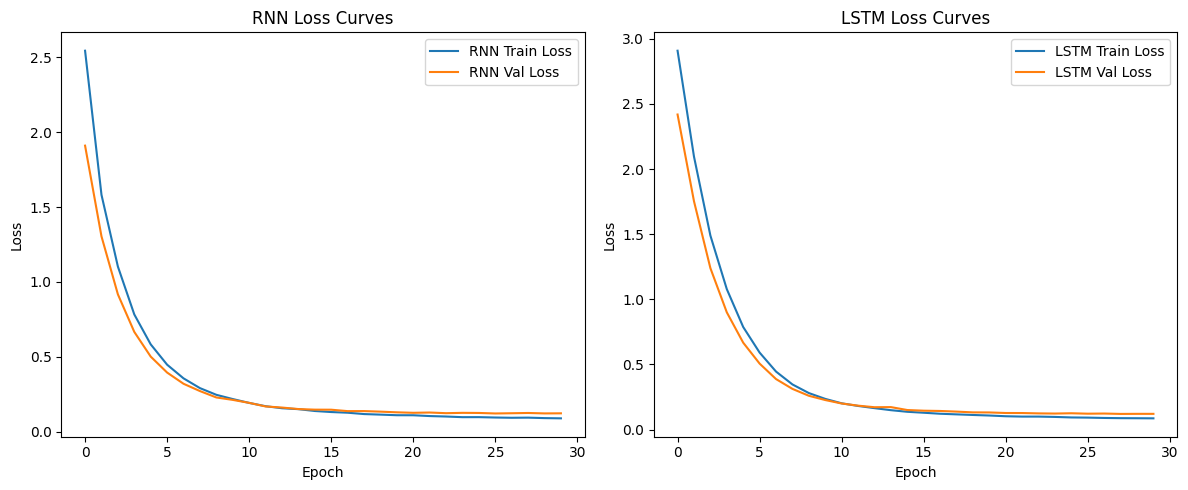

In [56]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(rnn_train_losses, label='RNN Train Loss')
plt.plot(rnn_val_losses, label='RNN Val Loss')
plt.title('RNN Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(lstm_train_losses, label='LSTM Train Loss')
plt.plot(lstm_val_losses, label='LSTM Val Loss')
plt.title('LSTM Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [57]:
embed_dim = 64
hidden_dim = 128
num_layers = 2  
learning_rate = 0.001
epochs = 50
dropout = 0.2